#**Import Libraries.**

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay   # New!

#**Load the Dataset.**

In [ ]:
# Mount google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Read in file from folder structure--this is the cleaned version (still has null values)
filename = '/content/drive/MyDrive/AXSOSACADEMY/02-MachineLearning/Week06/titanic-cleaned.csv'
df = pd.read_csv(filename)
df = df.set_index('PassengerId')
df.head()

,Survived,Pclass,Name,Sex,Age,Siblings or Spouses,Parents or Children,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.28,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.93,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.10,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,NaN,S


#**Inspect**

In [ ]:
# Inspect data
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Survived             891 non-null    int64  
 1   Pclass               891 non-null    int64  
 2   Name                 891 non-null    object 
 3   Sex                  891 non-null    object 
 4   Age                  714 non-null    float64
 5   Siblings or Spouses  891 non-null    int64  
 6   Parents or Children  891 non-null    int64  
 7   Ticket               891 non-null    object 
 8   Fare                 891 non-null    float64
 9   Cabin                204 non-null    object 
 10  Embarked             889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


#**Define Features and Target and Train-Test Split**

In [ ]:
# Drop irrelevant and high cardinality features
cols_drop = ['Ticket', 'Cabin']
# Create features matrix and target vector
X = df.drop(columns = [*cols_drop, 'Survived'])
y = df['Survived']
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42)

#**Create Preprocessor**

**Categorical Preprocessing Pipeline**

In [ ]:
# Categorical Preprocessing Pipeline
# Save list of column names
ohe_cols = X_train.select_dtypes('object').columns
print("OneHotEncoder Columns:", ohe_cols)
# Instantiate the individual preprocessors
impute_na = SimpleImputer(strategy='constant', fill_value = "Missing")
ohe_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
# Make pipeline with imputer and encoder
ohe_pipe = make_pipeline(impute_na, ohe_encoder)
# Making a ohe_tuple for ColumnTransformer
ohe_tuple = ('categorical', ohe_pipe, ohe_cols)

OneHotEncoder Columns: Index(['Name', 'Sex', 'Embarked'], dtype='object')


**Numerical Preprocessing Pipeline**

In [ ]:
# Numerical Prepprocessing Pipeline
# Save list of column names
num_cols = X_train.select_dtypes("number").columns
print("Numeric Columns:", num_cols)
# instantiate preprocessors
impute_median = SimpleImputer(strategy='median')
scaler = StandardScaler()
# Make a numeric preprocessing pipeline
num_pipe = make_pipeline(impute_median, scaler)
# Making a numeric tuple for ColumnTransformer
num_tuple = ('numeric', num_pipe, num_cols)

Numeric Columns: Index(['Pclass', 'Age', 'Siblings or Spouses', 'Parents or Children', 'Fare'], dtype='object')


#**Create the Column Transformer**

In [ ]:
# Create the Column Transformer
preprocessor = ColumnTransformer([num_tuple, ohe_tuple], verbose_feature_names_out=False)

#**Instantiate and Fit the Default Model (using a model pipeline)**

In [ ]:
# Instantiate a default decision tree
dec_tree_class =DecisionTreeClassifier(random_state = 42)
# Make a pipeline to scale the data and fit a model
dec_tree_pipe = make_pipeline(preprocessor, dec_tree_class)
# Fit the model on the training data
dec_tree_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['Pclass', 'Age', 'Siblings or Spouses', 'Parents or Children', 'Fare'], dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Name', 'Sex', 'Embarked'], dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(random_state=42))])

#**Obtain Predictions and Evaluate the Model**

In [ ]:
# Define the predicted values
y_pred_train = dec_tree_pipe.predict(X_train)
y_pred_test = dec_tree_pipe.predict(X_test)
# Obtain the accuracy score
train_acc = round(accuracy_score(y_pred_train, y_train), 3)
test_acc = round(accuracy_score(y_pred_test, y_test), 3)
# Print the results
print(f'Training accuracy : {train_acc}.')
print(f'Testing accuracy  : {test_acc}.')

Training accuracy : 1.0.
Testing accuracy  : 0.816.


##**model is overfit**

#**Create a Confusion Matrix**

In [ ]:
# Create a confusion matrix
cm = confusion_matrix(y_test, y_pred_test)
cm

array([[117,  17],
       [ 24,  65]])

**117 = true negative**

**17 =false positive**

**24 = false negative**

**59 = true positive**



In [ ]:
# Convert confusion matrix to dataframe
cm_df = pd.DataFrame(cm)
cm_df

,0,1
0,117,17
1,24,65


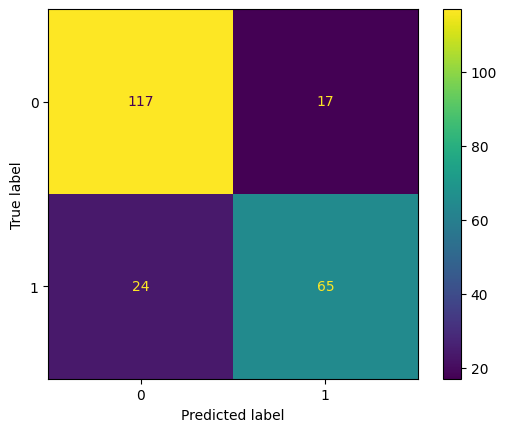

In [ ]:
# Plot the confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test);

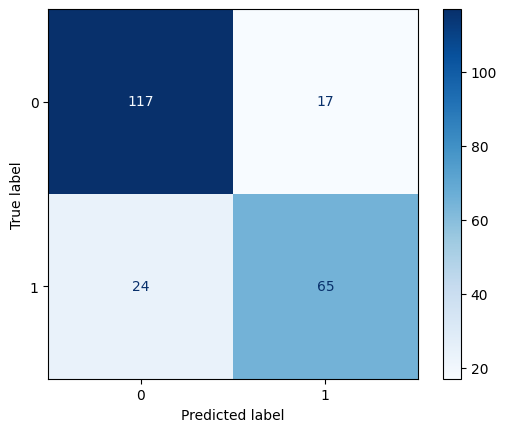

In [ ]:
# Plot the confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, cmap='Blues');

 the **positive class** refers to **"Survived,"**


 the **negative class** refers to **"Died."**


**True Negatives**:

117 passengers who actually died were predicted correctly as "died."

**True Positives:**

 65 passengers who survived were correctly predicted as "survived."

 117 + 65 + 24 + 17 = 223

 (117+65)/223 = 0.81(**The accuracy metric**)


 **False Negatives:**

  23 passengers who actually survived were predicted incorrectly as "died" by the model. **(Type 2 Error)**


  **False Positives:**
  
   17 passengers who actually died were predicted incorrectly as "survived" by the model. **(Type 1 Error)**






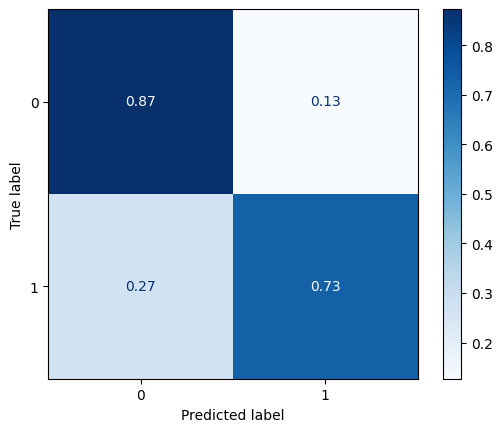

In [ ]:
# Plot the confusion matrix with ratios
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, cmap='Blues', normalize='true');


**true = أنا بعرف الحقيقة وبشوف التوقعات**

**pred = أنا بعرف التوقعات وبشوف الحقيقة**

In [ ]:
# Saving the confusion matrix counts as vars
TN = 117
FP = 17
FN = 24
TP = 85

In [ ]:
# Calculate Accuracy from Confusion Matrix Values
accuracy_eqn = (TP + TN ) / (TP+FP+TN+FN)
accuracy_eqn

0.831275720164609

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_sk = accuracy_score(y_test, y_pred_test)
accuracy_sk

0.8161434977578476

In [ ]:
# Calculate recall from confusion matrix values
recall_eqn = TP/ (FN+TP)
recall_eqn

0.7798165137614679

In [ ]:
from sklearn.metrics import recall_score
recall_sk = recall_score(y_test, y_pred_test, pos_label=1)
recall_sk

0.7303370786516854

الموديل اكتشف حوالي 77.9% من الحالات الإيجابية الحقيقية

👉 وضيّع حوالي 20.5% (ما قدر يلقطهم)

In [ ]:
# New import for classification_report
from sklearn.metrics import classification_report
# Print the classification report for decision tree predictions of titanic survivorship
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       134
           1       0.79      0.73      0.76        89

    accuracy                           0.82       223
   macro avg       0.81      0.80      0.81       223
weighted avg       0.81      0.82      0.81       223



**Precision = 0.83**

👉 لما الموديل يقول "هذا مات"، بيكون صح 83% من الوقت

---------------------------------------------------------------------

**Recall = 0.87**

👉 من كل الناس اللي فعلاً ماتوا، الموديل اكتشف 87% منهم

---------------------------------------------------------------------

**F1-score = 0.85**

👉 توازن بين precision و recall (أداء جيد)

---------------------------------------------------------------------

**Support = 134**

👉 عدد الناس الحقيقيين اللي ماتوا في البيانات

**Precision = 0.79**

👉 لما يقول "هذا نجا"، بيكون صح 79% من الوقت

---------------------------------------------------------------------


**Recall = 0.73**

👉 من كل الناس اللي نجوا فعلاً، اكتشف 73% فقط

---------------------------------------------------------------------


**F1-score = 0.76**

👉 أداء متوسط (أقل من class 0)

---------------------------------------------------------------------


**Support = 89**

👉 عدد الناجين الحقيقيين

**📊 Accuracy = 0.82**

👉 الموديل صح في 82% من كل التوقعات

**📊 Macro avg**

0.81 | 0.80 | 0.81

👉 متوسط بسيط بين الكلاسين (بدون وزن)

**📊 Weighted avg**

0.81 | 0.82 | 0.81

👉 متوسط لكن موزون حسب عدد البيانات في كل class

(يعني class 0 تأثيره أكبر لأنه عددهم أكثر)

**كل كلاس يتم تقييمه لوحده كأنه هو “الإيجابي”، لذلك بنشوف metrics لكل فئة مش بس واحدة.**

📌 تلخيص بسيط: Precision vs Recall و F1-score

**Precision** 👉 يهمني أكون دقيق

✔ لما أقول “إيجابي” يكون صح قدر الإمكان

❌ يقلل الـ **False Positives**

**Recall** 👉 يهمني ما أفوّت حالات إيجابية

✔ ألتقط أكبر عدد من الإيجابيات الحقيقية

❌ يقلل الـ **False Negatives**


**⚖️ أيهما أهم؟**

👉 ما في واحد أهم دائمًا

✔ كل واحد مهم حسب المشكلة

🔗 **F1-score**

👉 حل وسط بين Precision و Recall


💡 متى نستخدمه؟

لما نريد توازن بين الدقة وعدم تفويت الحالات

لما Precision و Recall الاثنين مهمين بنفس الدرجة

**Accuracy** → أداء عام للموديل

**Macro avg** → عدل بين الكلاسات (مهم للفهم الحقيقي)

**Weighted avg** → يتأثر بحجم البيانات (ممكن يخدعك)

📌 **تلخيص استخدام كل Metric (باختصار جدًا)**

* **Accuracy** 👉 سهل الفهم، لكن ممكن يكون مضلل إذا البيانات غير متوازنة.

* **Recall** 👉 نستخدمه لما مهم ما نفوّت الحالات الإيجابية (نريد نكتشف كل المرضى مثلًا).

* **Precision** 👉 نستخدمه لما الخطأ مكلف (ما بدنا نعطي إيجابي غلط لأنه فيه علاج خطير أو تكلفة عالية).

* **F1-score** 👉 أفضل مقياس شامل لأنه يوازن بين Precision و Recall، لكن صعب نشرحه لغير التقنيين.


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
# Get predictions from the model
y_pred_test = dec_tree_pipe.predict(X_test)
# Set the label for the header
label='Test Data'
# Get the classification report
report = classification_report(y_test, y_pred_test,)
## Print header and report
header = "-"*60
print(header, f" Classification Metrics: {label}", header, sep='\n')
print(report)

------------------------------------------------------------
 Classification Metrics: Test Data
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       134
           1       0.79      0.73      0.76        89

    accuracy                           0.82       223
   macro avg       0.81      0.80      0.81       223
weighted avg       0.81      0.82      0.81       223



**output_dict=True**

This will return a dictionary of results instead of a string.

In [ ]:
# Save dictionary of results with ouput_dict = True
class_report = classification_report(y_test, y_pred_test, output_dict=True)
class_report.keys()

dict_keys(['0', '1', 'accuracy', 'macro avg', 'weighted avg'])

In [ ]:
# showing the full classification report dictionary
class_report

{'0': {'precision': 0.8297872340425532,
  'recall': 0.8731343283582089,
  'f1-score': 0.850909090909091,
  'support': 134.0},
 '1': {'precision': 0.7926829268292683,
  'recall': 0.7303370786516854,
  'f1-score': 0.7602339181286549,
  'support': 89.0},
 'accuracy': 0.8161434977578476,
 'macro avg': {'precision': 0.8112350804359107,
  'recall': 0.8017357035049472,
  'f1-score': 0.8055715045188729,
  'support': 223.0},
 'weighted avg': {'precision': 0.8149787885628117,
  'recall': 0.8161434977578476,
  'f1-score': 0.8147203448218318,
  'support': 223.0}}

In [ ]:
# showing the dictionary as a dataframe (transposed)
pd.DataFrame(class_report).T

,precision,recall,f1-score,support
0,0.829787,0.873134,0.850909,134.000000
1,0.792683,0.730337,0.760234,89.000000
accuracy,0.816143,0.816143,0.816143,0.816143
macro avg,0.811235,0.801736,0.805572,223.000000
weighted avg,0.814979,0.816143,0.814720,223.000000


📄 **Classification Report** (وممكن كـ dict)

🟫 **Confusion Matrix** بالأرقام

🟦 **Confusion Matrix** بالنسب

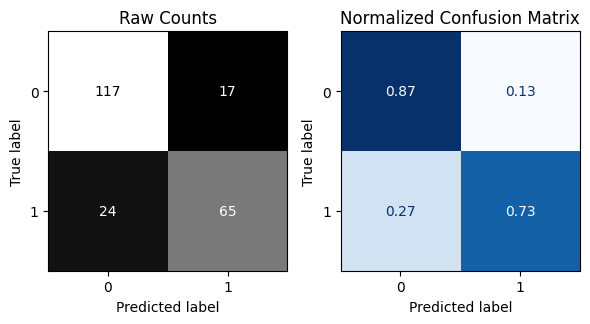

In [ ]:
# Creating test arguments/parameters
figsize=(6,4)
normalize='true'
cmap='Blues'
colorbar=False
## Creating the side by side plot axes
fig, axes = plt.subplots(ncols=2, figsize=figsize)
# create a confusion matrix  of raw counts
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test,
              normalize=None, cmap='gist_gray',colorbar=colorbar,
              ax = axes[0],);
axes[0].set_title("Raw Counts")
# create a confusion matrix with the test data
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test,
              normalize=normalize, cmap=cmap,colorbar=colorbar,
              ax = axes[1]);
axes[1].set_title("Normalized Confusion Matrix")
fig.tight_layout()

In [ ]:
def classification_metrics(y_true, y_pred, label='',
                           output_dict=False, figsize=(8,4),
                           normalize='true', cmap='Blues',
                           colorbar=False):
  # Get the classification report
  report = classification_report(y_true, y_pred)
  ## Print header and report
  header = "-"*70
  print(header, f" Classification Metrics: {label}", header, sep='\n')
  print(report)
  ## CONFUSION MATRICES SUBPLOTS
  fig, axes = plt.subplots(ncols=2, figsize=figsize)
  # create a confusion matrix  of raw counts
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=None, cmap='gist_gray', colorbar=colorbar,
                ax = axes[0],);
  axes[0].set_title("Raw Counts")
  # create a confusion matrix with the test data
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=normalize, cmap=cmap, colorbar=colorbar,
                ax = axes[1]);
  axes[1].set_title("Normalized Confusion Matrix")
  # Adjust layout and show figure
  fig.tight_layout()
  plt.show()
  # Return dictionary of classification_report
  if output_dict==True:
    report_dict = classification_report(y_true, y_pred, output_dict=True)
    return report_dict

----------------------------------------------------------------------
 Classification Metrics: 
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       134
           1       0.79      0.73      0.76        89

    accuracy                           0.82       223
   macro avg       0.81      0.80      0.81       223
weighted avg       0.81      0.82      0.81       223



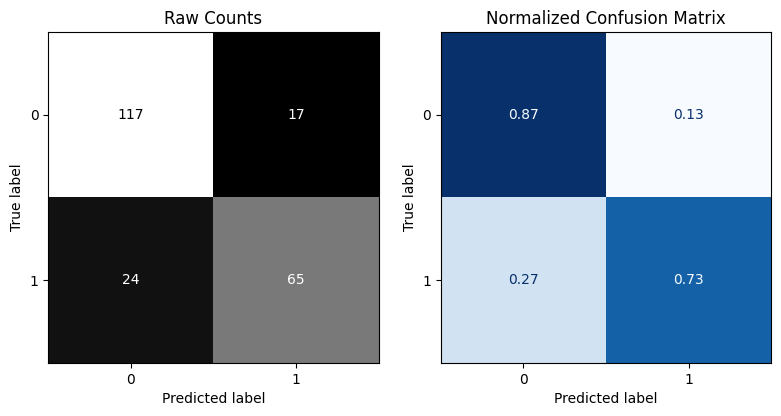

In [ ]:
# Test the evalution_metrics helper function
classification_metrics(y_test, y_pred_test)

In [ ]:
def evaluate_classification(model, X_train, y_train, X_test, y_test,
                         figsize=(6,4), normalize='true', output_dict = False,
                            cmap_train='Blues', cmap_test="Reds",colorbar=False):
  # Get predictions for training data
  y_train_pred = model.predict(X_train)
  # Call the helper function to obtain regression metrics for training data
  results_train = classification_metrics(y_train, y_train_pred, #verbose = verbose,
                                     output_dict=True, figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_train,
                                     label='Training Data')
  print()
  # Get predictions for test data
  y_test_pred = model.predict(X_test)
  # Call the helper function to obtain regression metrics for test data
  results_test = classification_metrics(y_test, y_test_pred, #verbose = verbose,
                                  output_dict=True,figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_test,
                                    label='Test Data' )
  if output_dict == True:
    # Store results in a dataframe if ouput_frame is True
    results_dict = {'train':results_train,
                    'test': results_test}
    return results_dict

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       415
           1       1.00      1.00      1.00       253

    accuracy                           1.00       668
   macro avg       1.00      1.00      1.00       668
weighted avg       1.00      1.00      1.00       668



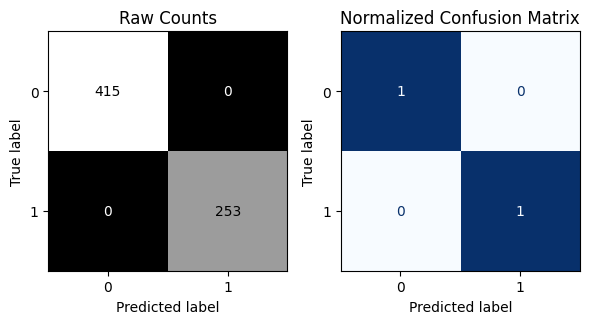


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       134
           1       0.79      0.73      0.76        89

    accuracy                           0.82       223
   macro avg       0.81      0.80      0.81       223
weighted avg       0.81      0.82      0.81       223



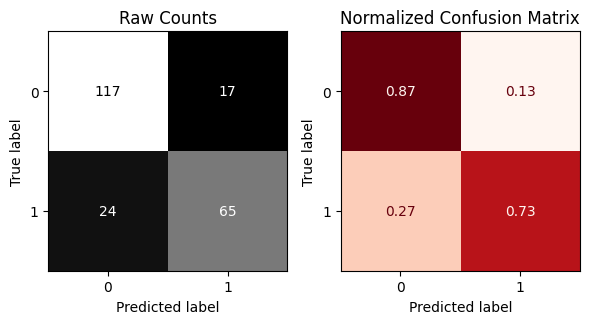

In [ ]:
# Test the function
results = evaluate_classification(dec_tree_pipe,X_train, y_train, X_test, y_test,output_dict=True)